In [1]:
import numpy as np
import scipy.sparse as sp
import matplotlib as mpl
import matplotlib.pyplot as plt
import tenpy
import tenpy.linalg.np_conserved as npc
from tenpy import version as v
print(v.version_summary)

from tenpy.networks.site import BosonSite, SpinSite, GroupedSite, set_common_charges
from tenpy.models.lattice import Lattice, IrregularLattice
from tenpy.models.model import CouplingModel
import tenpy.models.lattice as lattice

from tenpy.networks.mps import MPS
from tenpy.algorithms import tebd, dmrg, tdvp

from tenpy.algorithms.mpo_evolution import ExpMPOEvolution
from tenpy.algorithms.exact_diag import ExactDiag
from tenpy.algorithms.dmrg import TwoSiteDMRGEngine
from tenpy.algorithms.tebd import TEBDEngine


import time
import os
import json
from matplotlib import cm


tenpy 1.1.0 (compiled without HAVE_MKL),
git revision unknown using
python 3.12.2 | packaged by Anaconda, Inc. | (main, Feb 27 2024, 17:35:02) [GCC 11.2.0]
numpy 2.3.5, scipy 1.17.0


In [2]:
from SpinBosonEnv.GeneralSpinBosonEnv import GeneralSpinBosonEnv
from SpinBosonEnv.CavityArrayAtom import CavityArrayAtom

In [3]:
with open("/home/ihuarte/Escritorio/Ivan/MPS/config.json", "r") as f:
    config = json.load(f)

SB_params = config["SB_params"]
model_params = config["model_params"]
DMRG_options = config["DMRG_options"]

for k, v in SB_params.items():
    SB_params[k] = np.pi if v == "pi" else v


env_SB = GeneralSpinBosonEnv(SB_params)
print(f"Hk: {env_SB.Hk.shape}")
print(f"Hmap: {env_SB.Hmap.shape}")


model_params["L"] = len(env_SB.wlist)
model_params["w"] = env_SB.wlist
model_params["delta"] = SB_params["delta"] 
model_params["g"] = env_SB.g0
model_params["J"] = env_SB.Jlist

caa = CavityArrayAtom(model_params, DMRG_options)



g0 1.5000000000000002
Hk: (801, 801)
Hmap: (526, 526)


# Wk


In [29]:
# k_list = env_SB.k
# w0 = SB_params["w0"]
# wc = SB_params["wc"]
Nk = 71

k_list = np.linspace(-np.pi, np.pi, Nk)
w0 = 1.0
wc = 10
wk = w0 * wc / np.sqrt(w0**2 + 2 * wc**2 * (1 - np.cos(k_list)))

w_min = w0 * wc / np.sqrt(w0**2 + 4 * wc**2)
w_min

np.float64(0.49937616943892227)

8.761535447285983
8.759831378463463
Error 0.019453214895311086%


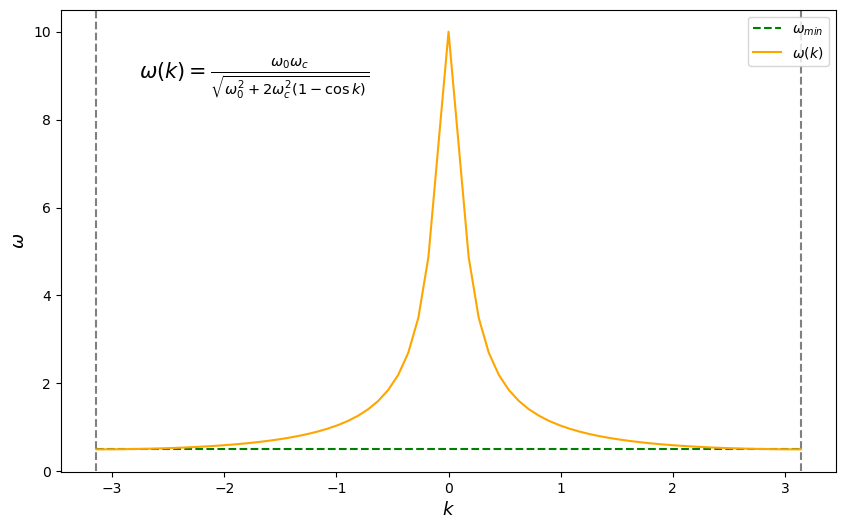

In [30]:
fig, ax = plt.subplots(figsize=[10, 6])
ax.set_ylim(-0.01, wc + wc/20)
ax.set_xlabel(r"$k$", fontsize=13)
ax.set_ylabel(r"$\omega$", fontsize=13)
ax.vlines(-np.pi, 0, wc + wc/20, color = "grey", ls = "--")
ax.vlines(np.pi, 0, wc + wc/20, color = "grey", ls = "--")
ax.hlines(w_min, k_list[0], k_list[-1], color = "green", ls = "--", label = r"$\omega_{min}$")
ax.plot(k_list, wk, color = "orange", label=r"$\omega(k)$")
ax.text(0.1, 0.85, r"$\omega(k)=\frac{\omega_0 \omega_c}{\sqrt{\omega_0^2 + 2\omega_c^2 (1-\cos{k})}}$", transform=ax.transAxes, fontsize=15)
ax.legend()

area_aprox = np.trapezoid(wk, k_list)
k_good = np.linspace(-np.pi, np.pi, 100000000)
wk_good = w0 * wc / np.sqrt(w0**2 + 2 * wc**2 * (1 - np.cos(k_good)))
area_good = np.trapezoid(wk_good, k_good)

print(area_aprox)
print(area_good)
print(f"Error {100 * np.abs(area_aprox - area_good)/ area_good}%")

In [ ]:
# Tabla Nk <---> wc de forma que el error en area <= 0.1 %

wc = 1000  Nk = 5001
wc = 100   Nk = 501
wc = 50   Nk = 301
wc = 10   Nk = 101
wc = 5   Nk = 101


# J(w)

In [8]:
w0 = SB_params["w0"]
wc = SB_params["wc"]
g = SB_params["g"]

w_list = np.arange(w_min + 0.001, wc-0.0000001, 0.000001)

Jw = 2 * g**2 * w0**2 / (w_list**3 * np.sqrt(1 - (1 - w0**2 * (1/w_list**2 - 1/wc**2) / 2)**2)) 
Jw

array([283.91631683, 283.77375691, 283.63141011, ...,   5.19901351,
         6.36920524,   9.01487509], shape=(49499025,))

/home/ihuarte/miniconda3/envs/conda_env/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/home/ihuarte/miniconda3/envs/conda_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


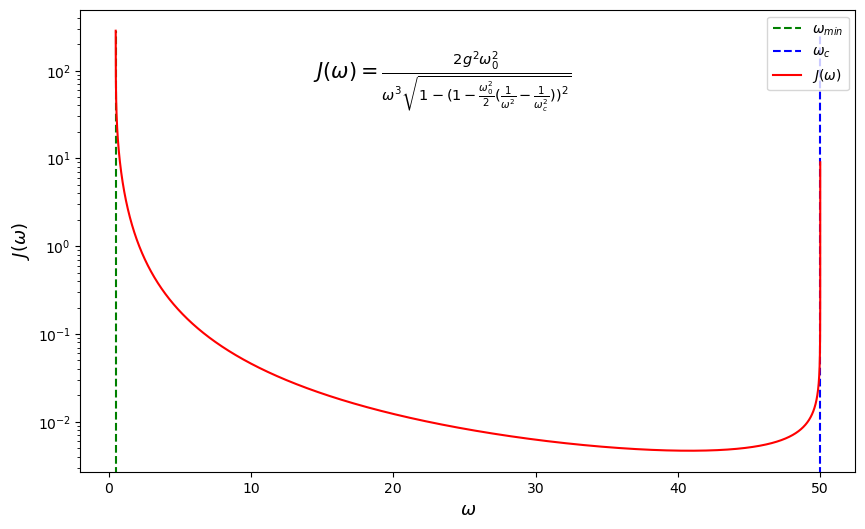

In [9]:
fig, ax = plt.subplots(figsize=[10, 6])
# ax.set_ylim(-0.01, wc + wc/20)
ax.set_xlabel(r"$\omega$", fontsize=13)
ax.set_ylabel(r"$J(\omega)$", fontsize=13)
ax.vlines(w_min, 0, max(Jw), color = "green", ls = "--", label=r"$\omega_{min}$")
ax.vlines(wc, 0, max(Jw), color = "blue", ls = "--", label=r"$\omega_c$")
# ax.vlines(np.pi, 0, wc + wc/20, color = "grey", ls = "--")

ax.plot(w_list, Jw, color = "red", label=r"$J(\omega)$")
ax.text(0.3, 0.85, r"$J(\omega)=\frac{ 2g^2\omega_0^2}{\omega^3\sqrt{1-(1-\frac{\omega_0^2}{2} (\frac{1}{\omega^2} - \frac{1}{\omega_c^2}))^2}} $", transform=ax.transAxes, fontsize=15)
ax.set_yscale("log")
ax.legend()

In [4]:
""" GROUND STATE AND ENERGY """

initial_state = caa.InitialState(config=[], GS=False)
eng = TwoSiteDMRGEngine(initial_state, caa, config["DMRG_options"])
E_gr, psi_gr = eng.run()

/home/ihuarte/miniconda3/envs/conda_env/lib/python3.12/site-packages/tenpy/networks/mps.py:1629: UserWarning: unit_cell_width is a new argument for MPS and similar classes. It is optional for now, but will become mandatory in a future release. The default value (unit_cell_width=len(sites)) is correct, iff the lattice is a Chain. For other lattices, it is incorrect. It is used for dipolar charges and correlation_function2.
  super().__init__(sites, bc, unit_cell_width)


In [ ]:
# E_gr.append(E_run)                
#N=psi_gr.expectation_value(Caa.OperatorChain('N'),Caa.bs_idx)
Sz=psi_gr.expectation_value('Sz',caa.atpos_idx)
Sx=psi_gr.expectation_value('Sx',caa.atpos_idx)
Sy=psi_gr.expectation_value('Sy',caa.atpos_idx)
Sbond=psi_gr.entanglement_entropy(n=1)[0]
N = psi_gr.expectation_value(caa.OperatorChain("N"), caa.bs_idx)

print('E_run:%.2f '%E_gr)
print('Sz: ',Sz)
print('Sx',Sx)
print('Sy',Sy)
print('Entanglement_S:',Sbond,'\n\n')
print('N ocupation:',N,'\n')

E_run:-2.66 
Sz:  [-0.03014556]
Sx [1.45443524e-11]
Sy [0.]
Entanglement_S: 0.6913285676943391 


N ocupation: [2.26962478e+00 3.16270814e-01 9.67499390e-02 2.61491162e-02
 7.07633834e-03 1.91826937e-03 5.20651166e-04 1.39328734e-04
 3.53311788e-05 8.17586512e-06 1.69906852e-06 3.16244744e-07
 5.27827723e-08 7.91409935e-09 1.06771129e-09 1.29776276e-10
 1.42234732e-11 1.40638797e-12 1.25477134e-13 1.00998407e-14
 7.33081210e-16 4.79452419e-17 2.82251304e-18 1.49348752e-19
 6.92003307e-21 3.05995624e-22 1.84805143e-22 7.05781897e-24
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00

In [ ]:
C=psi_gr.correlation_function(caa.OperatorChain('Bd'),caa.OperatorChain('B'),caa.bs_idx,caa.bs_idx)

In [10]:
Map2Xcontraction(C,env_SB.basis)

Preparando matrices 

TimeExe:  6.198883056640625e-06 " 


1º Contraccion: C[b][bp]-Q[kp][b] ---> QC[bp][kp]
TimeExe:  0.12180614471435547 " 


2º Contraccion: QC[bp][kp]-K[bp][k] ---> QCK[kp][k]
TimeExe:  0.17939376831054688 " 


3º Contraccion: QCK[kp][k]-U[n][k][kp] ---> QCKU[k][n][k]


/tmp/ipykernel_32347/3386136973.py:46: ComplexWarning: Casting complex values to real discards the imaginary part
  QCKU[k][n][k]=np.sum([QCK[kp][k]*np.exp(cte*(k-kp)*(n-n0)) for kp in range(N)])  # ESTE ES EL MAS GORDO


TimeExe:  0.7356362342834473 " 


4º Contraccion: QCKU[k][n][k]---> B[n]
TimeExe:  0.0016417503356933594 " 




array([1.66533454e-18, 6.55767449e-07, 2.60465041e-06, 5.79384072e-06,
       1.01447810e-05, 1.55635304e-05, 2.19580119e-05, 2.92486757e-05,
       3.73894866e-05, 4.63713103e-05, 5.62440676e-05, 6.71089324e-05,
       7.91435774e-05, 9.25830113e-05, 1.07753268e-04, 1.25041901e-04,
       1.44946731e-04, 1.68035642e-04, 1.95017289e-04, 2.26687310e-04,
       2.64028956e-04, 3.08140105e-04, 3.60374645e-04, 4.22241731e-04,
       4.95603808e-04, 5.82535700e-04, 6.85603072e-04, 8.07663209e-04,
       9.52259963e-04, 1.12333937e-03, 1.32581672e-03, 1.56516655e-03,
       1.84824991e-03, 2.18271675e-03, 2.57823716e-03, 3.04561885e-03,
       3.59868846e-03, 4.25296780e-03, 5.02865386e-03, 5.94860485e-03,
       7.04331825e-03, 8.34786956e-03, 9.91097688e-03, 1.17906869e-02,
       1.40736089e-02, 1.68719695e-02, 2.03784789e-02, 2.48999057e-02,
       3.11543821e-02, 4.11550207e-02, 2.26962478e+00, 4.11550207e-02,
       3.11543821e-02, 2.48999057e-02, 2.03784789e-02, 1.68719695e-02,
      

In [9]:

def Map2Xcontraction(C,Q): #C[b][bp] = <b_n^+ b_m>  || Qd = Matriz cambio de base mapping  ----> return <a_n^+ a_n>)
    '''
    DESARROLLO EN LAS NOTAS... Con esto reducimos la complejidad de O(N^5) hasta O(3N^3)...se podria hacer con np.tensordot()
    C[b][bp] = <b_n^+ b_m>  (Nm x Nm)
    Q[kp][b] = Matriz cambio de base mapping (N x Nm)
    K[bp][k] = Q[k][bp]^+ Cambio de base traspuesta (Nm x N)
    U[n][k][kp] = 3-tensor de exp(-i(k-kp)n)  ----> Implementado directamente para ahorrar RAM
    '''
    print('Preparando matrices \n')
    ti=time.time()
    
    N=Q.shape[0]
    Nm=Q.shape[1]
    #U=np.array([[[np.exp(-1j*(k-kp)*n)/N for kp in range(N)]for k in range(N)]for n in range(N)])
    K=Q.T.conjugate() 
    tf=time.time()
    print('TimeExe: ',tf-ti,'\" \n\n')
    '''1º Contraccion: C[b][bp]-Q[kp][b] ---> QC[bp][kp]'''
    print('1º Contraccion: C[b][bp]-Q[kp][b] ---> QC[bp][kp]')
    ti=time.time()
    QC=np.zeros([Nm,N])
    for bp in range(Nm):
        for kp in range(N):
            QC[bp][kp]= np.sum([C[b][bp]*Q[kp][b] for b in range(Nm)])
    tf=time.time()
    print('TimeExe: ',tf-ti,'\" \n\n')
    
    '''2º Contraccion: QC[bp][kp]-K[bp][k] ---> QCK[kp][k]'''
    print('2º Contraccion: QC[bp][kp]-K[bp][k] ---> QCK[kp][k]')
    ti=time.time()
    QCK=np.zeros([N,N])
    for kp in range(N):
        for k in range(N):
            QCK[kp][k]= np.sum([QC[bp][kp]*K[bp][k] for bp in range(Nm)])
    tf=time.time()
    print('TimeExe: ',tf-ti,'\" \n\n')
    
    '''3º Contraccion: QCK[kp][k]-U[n][k][kp] ---> QCKU[k][n][k]'''
    print('3º Contraccion: QCK[kp][k]-U[n][k][kp] ---> QCKU[k][n][k]')
    ti=time.time()
    QCKU=np.zeros([N,N,N])
    cte=-1j*2*np.pi/N  #Para que k y kp vaya de 0 a N
    n0=N//2 # Para que salga centrado en 0
    for k in range(N):
        for n in range(N):
            QCKU[k][n][k]=np.sum([QCK[kp][k]*np.exp(cte*(k-kp)*(n-n0)) for kp in range(N)])  # ESTE ES EL MAS GORDO
    QCKU/=N
    tf=time.time()
    print('TimeExe: ',tf-ti,'\" \n\n')
    
    '''4º Contraccion: QCKU[k][n][k]---> B[n]'''
    print('4º Contraccion: QCKU[k][n][k]---> B[n]')
    ti=time.time()
    
    B=np.zeros([N])
    for n in range(N):
        B[n]=np.sum([QCKU[k][n][k] for k in range(N)])
    
    tf=time.time()
    print('TimeExe: ',tf-ti,'\" \n\n')
    
    return B
    
def Map2K(B,Q): #B = <b_n^+ b_m>  || Qkn =Matriz cambio de base mapping  ----> return <a_k^+ a_k'>
    Nk=len(B)
    N=Q.shape[0]
    M=Q.shape[1]
    Qd=Q.transpose().conjugate()
    Pout=np.zeros([Nk,Nk])
    
    for k in range(Nk):
        for kp in range(Nk):
            Pout[k][kp]=np.sum([[B[n][m]*Qd[k][m]*Q[kp][n] for m in range(M)] for n in range(N)]) 
            
    return Pout
    
def K2X(B):
    N=B.shape[0]
    Pout=np.zeros([N])
    for n in range(N):
        Pout[n]=np.sum([[ B[k][kp]*np.exp(-1j*(k-kp)*n) for kp in range(N)]for k in range(N)])
        
    return Pout

def Map2X(B,Q): #B = <b_n^+ b_m>  || Qkn = Matriz cambio de base mapping  ----> return <a_n^+ a_n>)
    return K2X(Map2K(B,Q))

NameError: name 'k_list' is not defined

In [26]:
from pprint import pprint

for name, term in caa.Cm.coupling_terms.items():
    print(name)
    coup = term.__dict__["coupling_terms"]
    for k, v in coup.items():
        print(f"{k}    {v}")
    print("\n")

local B Bd
1    {('B', 'Id'): {np.int64(2): {'Bd': np.float64(-0.3695283718006163)}}, ('Bd', 'Id'): {np.int64(2): {'B': np.float64(-0.3695283718006163)}}}
2    {('B', 'Id'): {np.int64(3): {'Bd': np.float64(-0.2651554738427654)}}, ('Bd', 'Id'): {np.int64(3): {'B': np.float64(-0.2651554738427654)}}}
3    {('B', 'Id'): {np.int64(4): {'Bd': np.float64(-0.26445514538592163)}}, ('Bd', 'Id'): {np.int64(4): {'B': np.float64(-0.26445514538592163)}}}
4    {('B', 'Id'): {np.int64(5): {'Bd': np.float64(-0.26445591787801803)}}, ('Bd', 'Id'): {np.int64(5): {'B': np.float64(-0.26445591787801803)}}}
5    {('B', 'Id'): {np.int64(6): {'Bd': np.float64(-0.2644566626747414)}}, ('Bd', 'Id'): {np.int64(6): {'B': np.float64(-0.2644566626747414)}}}
6    {('B', 'Id'): {np.int64(7): {'Bd': np.float64(-0.26445737679904335)}}, ('Bd', 'Id'): {np.int64(7): {'B': np.float64(-0.26445737679904335)}}}
7    {('B', 'Id'): {np.int64(8): {'Bd': np.float64(-0.26445806190125204)}}, ('Bd', 'Id'): {np.int64(8): {'B': np.float6